## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 3: MNIST Digit Classification
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


c:\Users\manju\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9346 - loss: 0.2148 - val_accuracy: 0.9847 - val_loss: 0.0508
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9800 - loss: 0.0656 - val_accuracy: 0.9883 - val_loss: 0.0325
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9851 - loss: 0.0484 - val_accuracy: 0.9913 - val_loss: 0.0315
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9881 - loss: 0.0384 - val_accuracy: 0.9917 - val_loss: 0.0298
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9899 - loss: 0.0310 - val_accuracy: 0.9918 - val_loss: 0.0304
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.9923 - val_loss: 0.0295
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9932 - loss: 0.0211 - val_accuracy: 0.9923 - val_loss: 0.0315
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9935 - loss: 0.0190 - val_acc

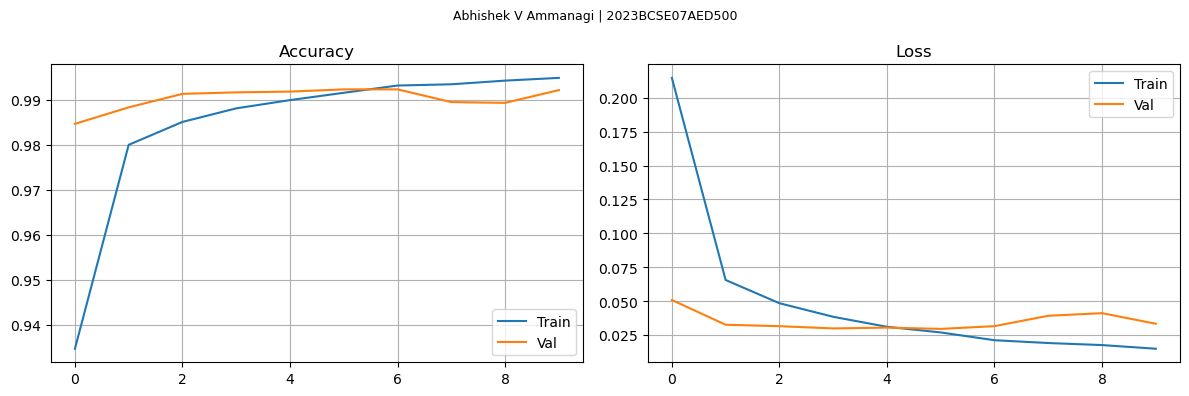

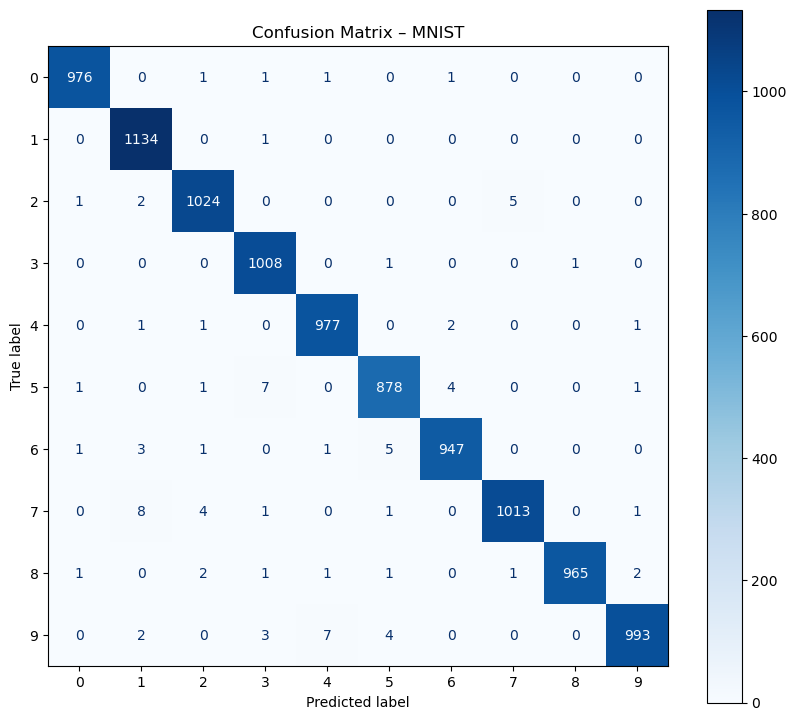

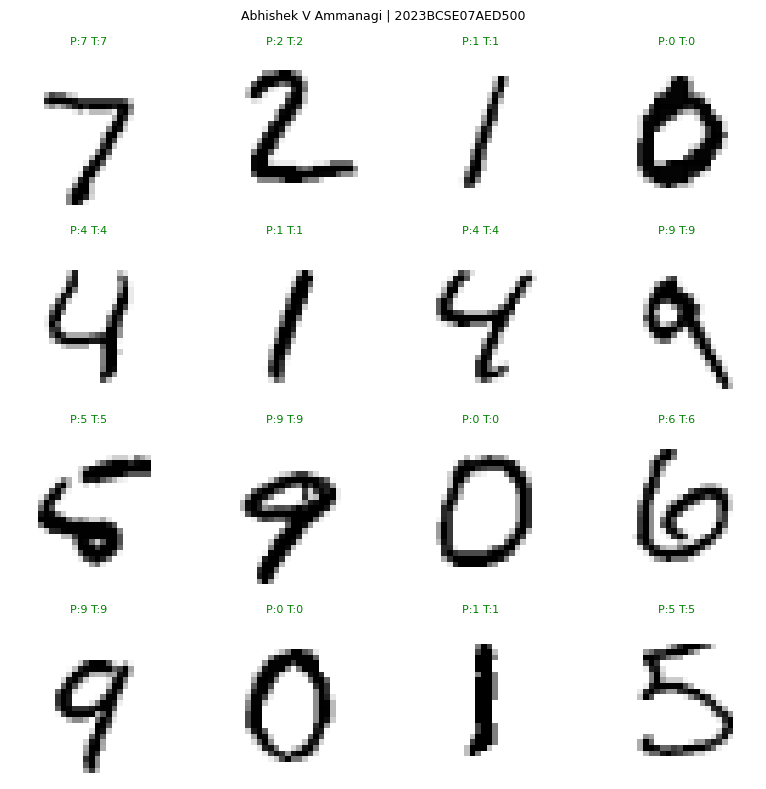

Abhishek V Ammanagi | 2023BCSE07AED500


: 

In [ ]:
# Experiment 3 – MNIST Digit Classification
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 3: MNIST Digit Classification")
print("=" * 55)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1,  28, 28, 1).astype("float32") / 255.0
y_tr_c  = to_categorical(y_train, 10)
y_te_c  = to_categorical(y_test,  10)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10,  activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_tr_c,
                    epochs=10, batch_size=64,
                    validation_split=0.1, verbose=1)

loss, acc = model.evaluate(X_test, y_te_c, verbose=0)
y_pred    = np.argmax(model.predict(X_test), axis=1)
print(f"\nTest Accuracy : {acc:.4f}")
print(f"Test Loss     : {loss:.4f}")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'],     label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(history.history['loss'],     label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp3_curves.png', dpi=300); plt.show()

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
fig, ax2 = plt.subplots(figsize=(10,9))
disp.plot(ax=ax2, cmap='Blues')
plt.title("Confusion Matrix – MNIST")
plt.savefig('exp3_cm.png', dpi=300); plt.show()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax3 in enumerate(axes.flat):
    ax3.imshow(X_test[i].reshape(28,28), cmap='gray_r')
    col = 'green' if y_pred[i]==y_test[i] else 'red'
    ax3.set_title(f"P:{y_pred[i]} T:{y_test[i]}", color=col, fontsize=8)
    ax3.axis('off')
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp3_preds.png', dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._